# Bootstrap estimation

Case-resampling bootstrap over each estimation stage's fit (`first_estimation`,
`second_estimation`, `third_estimation`): resample the 22 experimental
conditions with replacement, refit `theta` on each resample starting from
that stage's own fitted `theta_hat_full_<stage>`, and build an empirical
distribution of the fitted (free) parameters.

Each resample is an independent call to
`GlycolysisParameterEstimator(conditions=resampled_list, theta_init=theta_hat_full_<stage>, ...).estimate()`.
The loop is embarrassingly parallel; see `run_bootstrap_estimation(..., n_jobs=...)`
in `src/param_estimation_parmest.py` for the optional parallel path (default
`n_jobs=1`, sequential).

**Why there is no "fixed_estimation" stage here:** that stage's warm start
(`Data/theta_init_sampled.csv`) is a raw literature-sampled guess, not a
fitted result -- unlike first/second/third, which each warm-start from an
actual prior fit. Bootstrapping it means asking a single ipopt call (no
multistart) to re-derive a full 37-parameter fit from scratch, independently,
on every resample -- on a model already known to be rank-deficient/non-convex
at 37 free parameters. An earlier run of that stage confirmed this diverges
badly (e.g. `kcat_f_8` spanning [21, 692], `Ks_g6p_pgi` with CV > 150%), so
it has been dropped rather than left in as a misleading result.

In [ ]:
import sys
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_REPO_ROOT = os.path.abspath(".")
sys.path.insert(0, os.path.join(_REPO_ROOT, "src"))

from param_estimation_parmest import (
    GlycolysisParameterEstimator,
    available_conditions,
    check_solver,
    run_bootstrap_estimation,
)
from utils import metabolite_bounds

# Tunable globals
SEED = 0
N_BOOT = 1000   # pure single-shot estimate() per resample, no multistart --
              # cheap and consistent, so this can go higher than a
              # multistart-per-resample design would allow
N_JOBS = 10   # set >1 to parallelize the per-resample loop across processes

FIRST_ESTIMATION_DIR = os.path.join(_REPO_ROOT, "results", "first_estimation")
SECOND_ESTIMATION_DIR = os.path.join(_REPO_ROOT, "results", "second_estimation")
THIRD_ESTIMATION_DIR = os.path.join(_REPO_ROOT, "results", "third_estimation")
RESULTS_DIR = os.path.join(_REPO_ROOT, "results", "bootstrap_estimation")
os.makedirs(RESULTS_DIR, exist_ok=True)

CONDITIONS = sorted(available_conditions())
print("CONDITIONS (%d):" % len(CONDITIONS), CONDITIONS)

CONDITIONS (22): ['KO02', 'KO03', 'KO04', 'KO05', 'KO07', 'KO08', 'KO10', 'KO11', 'KO12', 'KO13', 'KO14', 'KO15', 'KO16', 'KO17', 'KO18', 'KO19', 'KO20', 'KO21', 'KO22', 'KO23', 'KO24', 'RF03']


## Bounds and solver options

Reuse `third_estimation`'s exact fit footing (identical `metabolite_bounds`
call and per-parameter `theta_bounds`) for every stage, so bootstrap
resamples are always drawn on the same bounds.

In [2]:
U_BOUNDS_DATA, X_BOUNDS_DATA = metabolite_bounds('Data', n_std=2,
                                                 mode=('log_std', 'data_range'),
                                                 slack=0.1)

v_max_min, v_max_max = [1, 100]
k_cat_min, k_cat_max = [0.1, 1000]
k_cat_fast_min, k_cat_fast_max = [50, 10000]
ks_min, ks_max = [1e-3, 20.0]
theta_bounds = {
    'v_max_1': [v_max_min, v_max_max],
    'Ka1_1': [ks_min, ks_max],
    'Ka2_1': [ks_min, ks_max],
    'Ka3_1': [ks_min, ks_max],
    'K_g6p_1': [ks_min, ks_max],
    'Ks_g6p_pgi': [ks_min, ks_max],
    'Kp_f6p_pgi': [ks_min, ks_max],
    'kcat_f_2': [k_cat_min, k_cat_max],
    'Ks_f6p_3': [ks_min, ks_max],
    'Ks_atp_3': [ks_min, ks_max],
    'Kp_fbp_3': [ks_min, ks_max],
    'Kp_adp_3': [ks_min, ks_max],
    'kcat_f_3': [k_cat_min, k_cat_max],
    'Ks_fbp_4': [ks_min, ks_max],
    'Kp_g3p_4': [ks_min, ks_max],
    'Kp_dhap_4': [ks_min, ks_max],
    'kcat_f_4': [k_cat_min, k_cat_max],
    'kcat_f_5': [k_cat_fast_min, k_cat_fast_max],
    'Ks_dhap_5': [ks_min, ks_max],
    'Kp_g3p_5': [ks_min, ks_max],
    'kcat_f_6': [k_cat_min, k_cat_max],
    'Ks_g3p_6': [ks_min, ks_max],
    'Ks_pi_6': [ks_min, ks_max],
    'Ks_nad_6': [ks_min, ks_max],
    'Kp_pgp_6': [ks_min, ks_max],
    'Kp_nadh_6': [ks_min, ks_max],
    'kcat_f_7': [k_cat_min, k_cat_max],
    'Ks_pgp_7': [ks_min, ks_max],
    'Ks_adp_7': [ks_min, ks_max],
    'Ks_3pg_7': [ks_min, ks_max],
    'Ks_atp_7': [ks_min, ks_max],
    'kcat_f_8': [k_cat_min, k_cat_max],
    'Ks_3pg_8': [ks_min, ks_max],
    'Ks_2pg_8': [ks_min, ks_max],
    'kcat_f_9': [k_cat_min, k_cat_max],
    'Ks_2pg_9': [ks_min, ks_max],
    'Ks_pep_9': [ks_min, ks_max],
}

solver_options = {
    "linear_solver": "mumps",
    "nlp_scaling_method": "gradient-based",
    "max_iter": 8000,
    "acceptable_iter": 15,
    "acceptable_tol": 1e-5,
    "tol": 1e-6,
    "mu_strategy": "adaptive",
    "bound_push": 1e-8,
    "bound_frac": 1e-8,
    "warm_start_init_point": "yes",
    "print_level": 0,
}

## Resamples: one fresh seeded RNG per stage

Each stage below creates its own `np.random.default_rng(SEED)` right before
drawing its resamples. Reusing the same `SEED` per stage (rather than sharing
one advancing RNG across stages) means every stage bootstraps the *identical*
resampled condition sets -- so differences in bootstrap spread across
first/second/third reflect the model/warm-start, not different resamples.

# First estimation bootstrapping

In [3]:
theta_init_sources_1 = pd.read_csv(os.path.join(FIRST_ESTIMATION_DIR, "theta_init_sources.csv"), index_col=0)
theta_fitted_1 = pd.read_csv(os.path.join(FIRST_ESTIMATION_DIR, "theta_fitted.csv"), index_col=0)

theta_hat_full_1 = theta_init_sources_1["value"].to_dict()
# theta_hat_full_1.update(theta_fitted_1["value"].to_dict())   # overlay fitted (free) values

free_params_1 = list(theta_init_sources_1.index)   # first_estimation fit all 37 params
fixed_params_1 = []

print("free params (%d):" % len(free_params_1), free_params_1)
print("fixed params (%d):" % len(fixed_params_1), fixed_params_1)

free params (37): ['v_max_1', 'Ka1_1', 'Ka2_1', 'Ka3_1', 'K_g6p_1', 'Ks_g6p_pgi', 'Kp_f6p_pgi', 'kcat_f_2', 'Ks_f6p_3', 'Ks_atp_3', 'Kp_fbp_3', 'Kp_adp_3', 'kcat_f_3', 'Ks_fbp_4', 'Kp_g3p_4', 'Kp_dhap_4', 'kcat_f_4', 'kcat_f_5', 'Ks_dhap_5', 'Kp_g3p_5', 'kcat_f_6', 'Ks_g3p_6', 'Ks_pi_6', 'Ks_nad_6', 'Kp_pgp_6', 'Kp_nadh_6', 'kcat_f_7', 'Ks_pgp_7', 'Ks_adp_7', 'Ks_3pg_7', 'Ks_atp_7', 'kcat_f_8', 'Ks_3pg_8', 'Ks_2pg_8', 'kcat_f_9', 'Ks_2pg_9', 'Ks_pep_9']
fixed params (0): []


In [4]:
rng_first = np.random.default_rng(SEED)
resamples_first = [
    list(rng_first.choice(CONDITIONS, size=len(CONDITIONS), replace=True))
    for _ in range(N_BOOT)
]
print("Built %d resamples of %d conditions each." % (len(resamples_first), len(CONDITIONS)))

Built 10000 resamples of 22 conditions each.


In [5]:
results_first = run_bootstrap_estimation(
    resamples_first, theta_hat_full_1, free_params_1, fixed_params_1,
    x_bounds=X_BOUNDS_DATA, u_bounds=U_BOUNDS_DATA,
    theta_bounds=theta_bounds, solver_options=solver_options,
    n_jobs=N_JOBS, verbose=True,
)

In [6]:
converged_first = [c for _, _, c in results_first]
bootstrap_theta_first = pd.DataFrame([theta for theta, _, c in results_first if c])
bootstrap_obj_first = [obj for _, obj, c in results_first if c]

bootstrap_theta_first["obj_value"] = bootstrap_obj_first
bootstrap_theta_first.to_csv(os.path.join(RESULTS_DIR, "bootstrap_theta_first_estimation.csv"), index=False)

summary_first = {
    "n_boot": N_BOOT,
    "n_converged": int(sum(converged_first)),
    "seed": SEED,
    "n_jobs": N_JOBS,
    "stats": {
        p: {
            "mean": float(bootstrap_theta_first[p].mean()),
            "std": float(bootstrap_theta_first[p].std()),
            "q025": float(bootstrap_theta_first[p].quantile(0.025)),
            "q975": float(bootstrap_theta_first[p].quantile(0.975)),
        }
        for p in free_params_1
    },
}
with open(os.path.join(RESULTS_DIR, "bootstrap_summary_first_estimation.json"), "w") as f:
    json.dump(summary_first, f, indent=2)

print("Converged: %d / %d" % (sum(converged_first), N_BOOT))
bootstrap_theta_first.describe()

Converged: 9831 / 10000


,v_max_1,Ka1_1,Ka2_1,Ka3_1,K_g6p_1,Ks_g6p_pgi,Kp_f6p_pgi,kcat_f_2,Ks_f6p_3,Ks_atp_3,...,Ks_adp_7,Ks_3pg_7,Ks_atp_7,kcat_f_8,Ks_3pg_8,Ks_2pg_8,kcat_f_9,Ks_2pg_9,Ks_pep_9,obj_value
count,9831.000000,9831.000000,9831.000000,9831.000000,9831.000000,9831.000000,9831.000000,9831.000000,9831.000000,9831.000000,...,9831.000000,9831.000000,9831.000000,9831.000000,9831.000000,9831.000000,9831.000000,9831.000000,9831.000000,9831.000000
mean,63.755248,0.089641,0.351629,3.327679,6.287820,1.967423,5.784701,227.143531,0.545322,0.804248,...,0.002701,6.706682,6.550174,268.398276,1.281083,5.417402,253.694615,1.568499,7.040813,110.430898
std,15.551484,0.188760,0.305525,2.181260,3.319534,2.753858,3.468023,210.511531,1.102154,1.589489,...,0.052795,3.119332,3.213149,205.258965,2.471632,3.618147,193.530365,2.739639,2.971328,77.963314
min,21.543397,0.001029,0.001062,0.193371,0.722555,0.001017,0.434817,18.489544,0.001000,0.001000,...,0.001000,0.185909,0.072585,9.621162,0.001000,0.001168,5.043727,0.001000,0.001041,0.939721
25%,51.689393,0.002644,0.073887,1.246987,3.038202,0.037532,2.475816,54.562253,0.028193,0.074206,...,0.001050,3.892714,3.639415,160.214305,0.001043,1.878485,89.353050,0.001172,4.321530,38.189281
50%,69.014952,0.024700,0.298618,2.923040,6.303321,0.310265,5.232816,123.901050,0.226440,0.342384,...,0.001102,6.971973,6.729289,182.336814,0.048315,4.751465,173.487803,0.003948,7.572562,109.178168
75%,77.484417,0.069846,0.526232,5.595915,9.994909,3.430974,9.851031,401.132392,0.735101,1.022505,...,0.001199,9.950000,9.934902,369.633513,1.447923,9.731199,416.002004,2.039745,9.964225,152.448071
max,99.818109,2.670447,1.744922,14.455987,14.687372,14.131508,17.346397,990.039325,19.675473,19.393968,...,2.811795,17.945203,17.944827,999.630654,17.874334,14.596700,993.307751,18.938410,19.716450,484.950832


# Second estimation bootstrapping

In [7]:
theta_init_sources_2 = pd.read_csv(os.path.join(SECOND_ESTIMATION_DIR, "theta_init_sources.csv"), index_col=0)
theta_fitted_2 = pd.read_csv(os.path.join(SECOND_ESTIMATION_DIR, "theta_fitted.csv"), index_col=0)

theta_hat_full_2 = theta_init_sources_2["value"].to_dict()
# theta_hat_full_2.update(theta_fitted_2["value"].to_dict())   # overlay fitted (free) values

free_params_2 = theta_init_sources_2[theta_init_sources_2["type"] == "free"].index.tolist()
fixed_params_2 = theta_init_sources_2[theta_init_sources_2["type"] == "fixed"].index.tolist()

print("free params (%d):" % len(free_params_2), free_params_2)
print("fixed params (%d):" % len(fixed_params_2), fixed_params_2)

free params (18): ['v_max_1', 'Ka2_1', 'Ka3_1', 'K_g6p_1', 'Ks_g6p_pgi', 'kcat_f_2', 'Ks_f6p_3', 'Ks_atp_3', 'kcat_f_3', 'Ks_fbp_4', 'kcat_f_4', 'kcat_f_5', 'kcat_f_6', 'kcat_f_7', 'kcat_f_8', 'Ks_3pg_8', 'kcat_f_9', 'Ks_2pg_9']
fixed params (19): ['Ka1_1', 'Kp_f6p_pgi', 'Kp_fbp_3', 'Kp_adp_3', 'Kp_g3p_4', 'Kp_dhap_4', 'Ks_dhap_5', 'Kp_g3p_5', 'Ks_g3p_6', 'Ks_pi_6', 'Ks_nad_6', 'Kp_pgp_6', 'Kp_nadh_6', 'Ks_pgp_7', 'Ks_adp_7', 'Ks_3pg_7', 'Ks_atp_7', 'Ks_2pg_8', 'Ks_pep_9']


In [8]:
rng_second = np.random.default_rng(SEED)
resamples_second = [
    list(rng_second.choice(CONDITIONS, size=len(CONDITIONS), replace=True))
    for _ in range(N_BOOT)
]
print("Built %d resamples of %d conditions each." % (len(resamples_second), len(CONDITIONS)))

Built 10000 resamples of 22 conditions each.


In [9]:
results_second = run_bootstrap_estimation(
    resamples_second, theta_hat_full_2, free_params_2, fixed_params_2,
    x_bounds=X_BOUNDS_DATA, u_bounds=U_BOUNDS_DATA,
    theta_bounds=theta_bounds, solver_options=solver_options,
    n_jobs=N_JOBS, verbose=True,
)

In [10]:
converged_second = [c for _, _, c in results_second]
bootstrap_theta_second = pd.DataFrame([theta for theta, _, c in results_second if c])
bootstrap_obj_second = [obj for _, obj, c in results_second if c]

bootstrap_theta_second["obj_value"] = bootstrap_obj_second
bootstrap_theta_second.to_csv(os.path.join(RESULTS_DIR, "bootstrap_theta_second_estimation.csv"), index=False)

summary_second = {
    "n_boot": N_BOOT,
    "n_converged": int(sum(converged_second)),
    "seed": SEED,
    "n_jobs": N_JOBS,
    "stats": {
        p: {
            "mean": float(bootstrap_theta_second[p].mean()),
            "std": float(bootstrap_theta_second[p].std()),
            "q025": float(bootstrap_theta_second[p].quantile(0.025)),
            "q975": float(bootstrap_theta_second[p].quantile(0.975)),
        }
        for p in free_params_2
    },
}
with open(os.path.join(RESULTS_DIR, "bootstrap_summary_second_estimation.json"), "w") as f:
    json.dump(summary_second, f, indent=2)

print("Converged: %d / %d" % (sum(converged_second), N_BOOT))
bootstrap_theta_second.describe()

Converged: 9999 / 10000


,v_max_1,Ka2_1,Ka3_1,K_g6p_1,Ks_g6p_pgi,kcat_f_2,Ks_f6p_3,Ks_atp_3,kcat_f_3,Ks_fbp_4,kcat_f_4,kcat_f_5,kcat_f_6,kcat_f_7,kcat_f_8,Ks_3pg_8,kcat_f_9,Ks_2pg_9,obj_value
count,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000
mean,74.458082,0.246942,5.925713,10.620224,6.125251,532.708456,0.708424,1.773033,711.456974,1.656218,69.228862,2337.636674,381.602093,881.228929,590.410798,3.678495,380.797491,2.174712,93.895601
std,5.588083,0.316058,1.103875,0.485377,2.009504,59.389066,0.263394,0.463560,32.218438,3.806100,151.336743,1571.511686,136.257101,170.295405,101.650652,2.136657,130.892784,3.028472,68.486008
min,43.378905,0.001224,0.052300,9.090598,0.001006,15.853549,0.139613,0.112341,552.079331,0.001000,2.718928,100.342069,4.791375,286.836281,7.393189,0.001011,12.663998,0.001022,1.834327
25%,70.845669,0.025730,5.266113,10.098654,5.533635,501.317672,0.593781,1.585927,684.792722,0.003047,3.651846,986.485903,348.231824,896.716611,541.513037,2.382300,252.985566,0.004819,34.289172
50%,73.371673,0.112553,5.915655,10.540200,6.682153,536.112817,0.664414,1.934822,705.860277,0.008003,4.151790,1604.878539,387.729947,970.405483,562.012267,3.011693,356.536946,0.534893,84.427976
75%,80.346940,0.329886,6.478030,11.142648,7.413436,574.426671,0.746974,2.036273,746.005466,0.094877,8.052913,3617.720359,491.967666,982.732064,665.440243,4.085793,492.564356,3.259217,135.354713
max,99.913915,1.846427,15.760174,11.564527,11.605034,993.071319,3.314315,7.200993,999.857215,19.999308,948.983833,8429.900503,994.304623,991.487728,995.618526,12.037207,998.174126,19.134548,550.661185


# Third estimation bootstrapping

In [11]:
theta_init_sources_third = pd.read_csv(os.path.join(THIRD_ESTIMATION_DIR, "theta_init_sources.csv"), index_col=0)

theta_hat_full_third = theta_init_sources_third["value"].to_dict()
# theta_hat_full_third.update(theta_fitted_third["value"].to_dict())   # overlay fitted (free) values

free_params_third = theta_init_sources_third[theta_init_sources_third["status"] == "free"].index.tolist()
fixed_params_third = theta_init_sources_third[theta_init_sources_third["status"] == "fixed"].index.tolist()

print("free params (%d):" % len(free_params_third), free_params_third)
print("fixed params (%d):" % len(fixed_params_third), fixed_params_third)

free params (16): ['v_max_1', 'Ka2_1', 'Ka3_1', 'K_g6p_1', 'Ks_g6p_pgi', 'kcat_f_2', 'kcat_f_3', 'Ks_fbp_4', 'kcat_f_4', 'kcat_f_5', 'kcat_f_6', 'kcat_f_7', 'kcat_f_8', 'Ks_3pg_8', 'kcat_f_9', 'Ks_2pg_9']
fixed params (21): ['Ka1_1', 'Kp_f6p_pgi', 'Ks_f6p_3', 'Ks_atp_3', 'Kp_fbp_3', 'Kp_adp_3', 'Kp_g3p_4', 'Kp_dhap_4', 'Ks_dhap_5', 'Kp_g3p_5', 'Ks_g3p_6', 'Ks_pi_6', 'Ks_nad_6', 'Kp_pgp_6', 'Kp_nadh_6', 'Ks_pgp_7', 'Ks_adp_7', 'Ks_3pg_7', 'Ks_atp_7', 'Ks_2pg_8', 'Ks_pep_9']


In [12]:
rng_third = np.random.default_rng(SEED)
resamples_third = [
    list(rng_third.choice(CONDITIONS, size=len(CONDITIONS), replace=True))
    for _ in range(N_BOOT)
]
print("Built %d resamples of %d conditions each." % (len(resamples_third), len(CONDITIONS)))

Built 10000 resamples of 22 conditions each.


In [13]:
results_third = run_bootstrap_estimation(
    resamples_third, theta_hat_full_third, free_params_third, fixed_params_third,
    x_bounds=X_BOUNDS_DATA, u_bounds=U_BOUNDS_DATA,
    theta_bounds=theta_bounds, solver_options=solver_options,
    n_jobs=N_JOBS, verbose=True,
)

KeyboardInterrupt: 

In [ ]:
converged_third = [c for _, _, c in results_third]
bootstrap_theta_third = pd.DataFrame([theta for theta, _, c in results_third if c])
bootstrap_obj_third = [obj for _, obj, c in results_third if c]

bootstrap_theta_third["obj_value"] = bootstrap_obj_third
bootstrap_theta_third.to_csv(os.path.join(RESULTS_DIR, "bootstrap_theta_third_estimation.csv"), index=False)

summary_third = {
    "n_boot": N_BOOT,
    "n_converged": int(sum(converged_third)),
    "seed": SEED,
    "n_jobs": N_JOBS,
    "stats": {
        p: {
            "mean": float(bootstrap_theta_third[p].mean()),
            "std": float(bootstrap_theta_third[p].std()),
            "q025": float(bootstrap_theta_third[p].quantile(0.025)),
            "q975": float(bootstrap_theta_third[p].quantile(0.975)),
        }
        for p in free_params_third
    },
}
with open(os.path.join(RESULTS_DIR, "bootstrap_summary_third_estimation.json"), "w") as f:
    json.dump(summary_third, f, indent=2)

print("Converged: %d / %d" % (sum(converged_third), N_BOOT))
bootstrap_theta_third.describe()

Converged: 5000 / 5000


,v_max_1,Ka2_1,Ka3_1,K_g6p_1,Ks_g6p_pgi,kcat_f_2,kcat_f_3,Ks_fbp_4,kcat_f_4,kcat_f_5,kcat_f_6,kcat_f_7,kcat_f_8,Ks_3pg_8,kcat_f_9,Ks_2pg_9,obj_value
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,70.730459,0.223882,6.609393,10.351615,6.451441,548.583751,643.015495,2.221827,93.622179,4071.926303,399.782634,839.511648,593.408789,3.451560,420.597306,2.411834,104.037205
std,4.570636,0.320582,1.211149,0.350129,1.863099,33.050101,92.942300,4.152811,168.182222,1024.819232,130.822244,187.083692,120.322409,2.372467,105.600152,3.194421,72.925614
min,20.005873,0.001036,0.098487,8.970765,0.001411,43.123176,274.713323,0.001000,2.718735,56.862612,4.748987,30.527774,9.219057,0.001003,4.744536,0.001002,2.866017
25%,67.991861,0.012372,6.032082,10.074271,5.726035,529.063363,579.831973,0.003209,3.688462,3114.761902,367.709360,704.521785,533.436572,2.111331,325.693096,0.003468,38.182031
50%,71.720942,0.047282,6.630421,10.167925,6.790504,548.546774,633.953939,0.030780,5.543877,4472.873300,433.455296,949.178775,596.437933,2.652293,428.633427,0.503442,96.936726
75%,73.118187,0.315768,7.248584,10.597816,7.732321,569.228031,723.151799,0.871170,41.494924,5029.744360,500.197019,978.729288,679.427573,3.570414,514.713336,4.823463,143.824841
max,99.609939,2.229800,17.034408,12.182681,18.747447,813.820302,915.143303,19.539206,582.637377,7306.205879,992.798739,989.976214,995.813755,19.065583,998.073333,18.489008,496.432111


## Bootstrap CI vs. the analytic (parmest) CI

Compare the empirical bootstrap percentile CI against the analytic
covariance-based CI already saved by `third_estimation.ipynb`.

In [ ]:
analytic_ci = pd.read_csv(os.path.join(THIRD_ESTIMATION_DIR, "confidence_intervals.csv"), index_col=0)

ci_compare = pd.DataFrame({
    "value": theta_fitted_third["value"],
    "boot_mean": pd.Series({p: summary_third["stats"][p]["mean"] for p in free_params_third}),
    "boot_q025": pd.Series({p: summary_third["stats"][p]["q025"] for p in free_params_third}),
    "boot_q975": pd.Series({p: summary_third["stats"][p]["q975"] for p in free_params_third}),
}).join(analytic_ci, how="left")
ci_compare

,value,boot_mean,boot_q025,boot_q975,theta,std_err,ci_low,ci_high,cv_percent
v_max_1,75.947702,70.730459,61.433128,77.885604,75.947702,1.000649e+09,-1.961272e+09,1.961272e+09,1.317550e+09
Ka2_1,0.065977,0.223882,0.001611,1.135031,0.065977,9.387311e+05,-1.839913e+06,1.839913e+06,1.422823e+09
Ka3_1,6.805770,6.609393,3.879452,8.840647,6.805770,9.407005e+07,-1.843773e+08,1.843773e+08,1.382210e+09
K_g6p_1,11.022370,10.351615,10.031332,11.022094,11.022370,5.681622e+08,-1.113598e+09,1.113598e+09,5.154628e+09
Ks_g6p_pgi,6.215532,6.451441,1.281781,8.922907,6.215532,3.838238e+01,-6.901393e+01,8.144500e+01,6.175236e+02
kcat_f_2,529.055657,548.583751,489.232236,605.078950,529.055657,3.107524e+03,-5.561691e+03,6.619802e+03,5.873718e+02
kcat_f_3,771.229593,643.015495,460.543560,781.584300,771.229593,1.398541e+06,-2.740370e+06,2.741912e+06,1.813392e+05
Ks_fbp_4,0.003137,2.221827,0.002351,11.823777,0.003137,5.194629e-03,-7.044463e-03,1.331848e-02,1.655917e+02
kcat_f_4,3.671319,93.622179,3.446752,466.595270,3.671319,1.648205e+00,4.408377e-01,6.901800e+00,4.489408e+01
kcat_f_5,2374.954464,4071.926303,2374.954474,5055.116857,2374.954464,8.227714e+05,-1.610257e+06,1.615007e+06,3.464367e+04


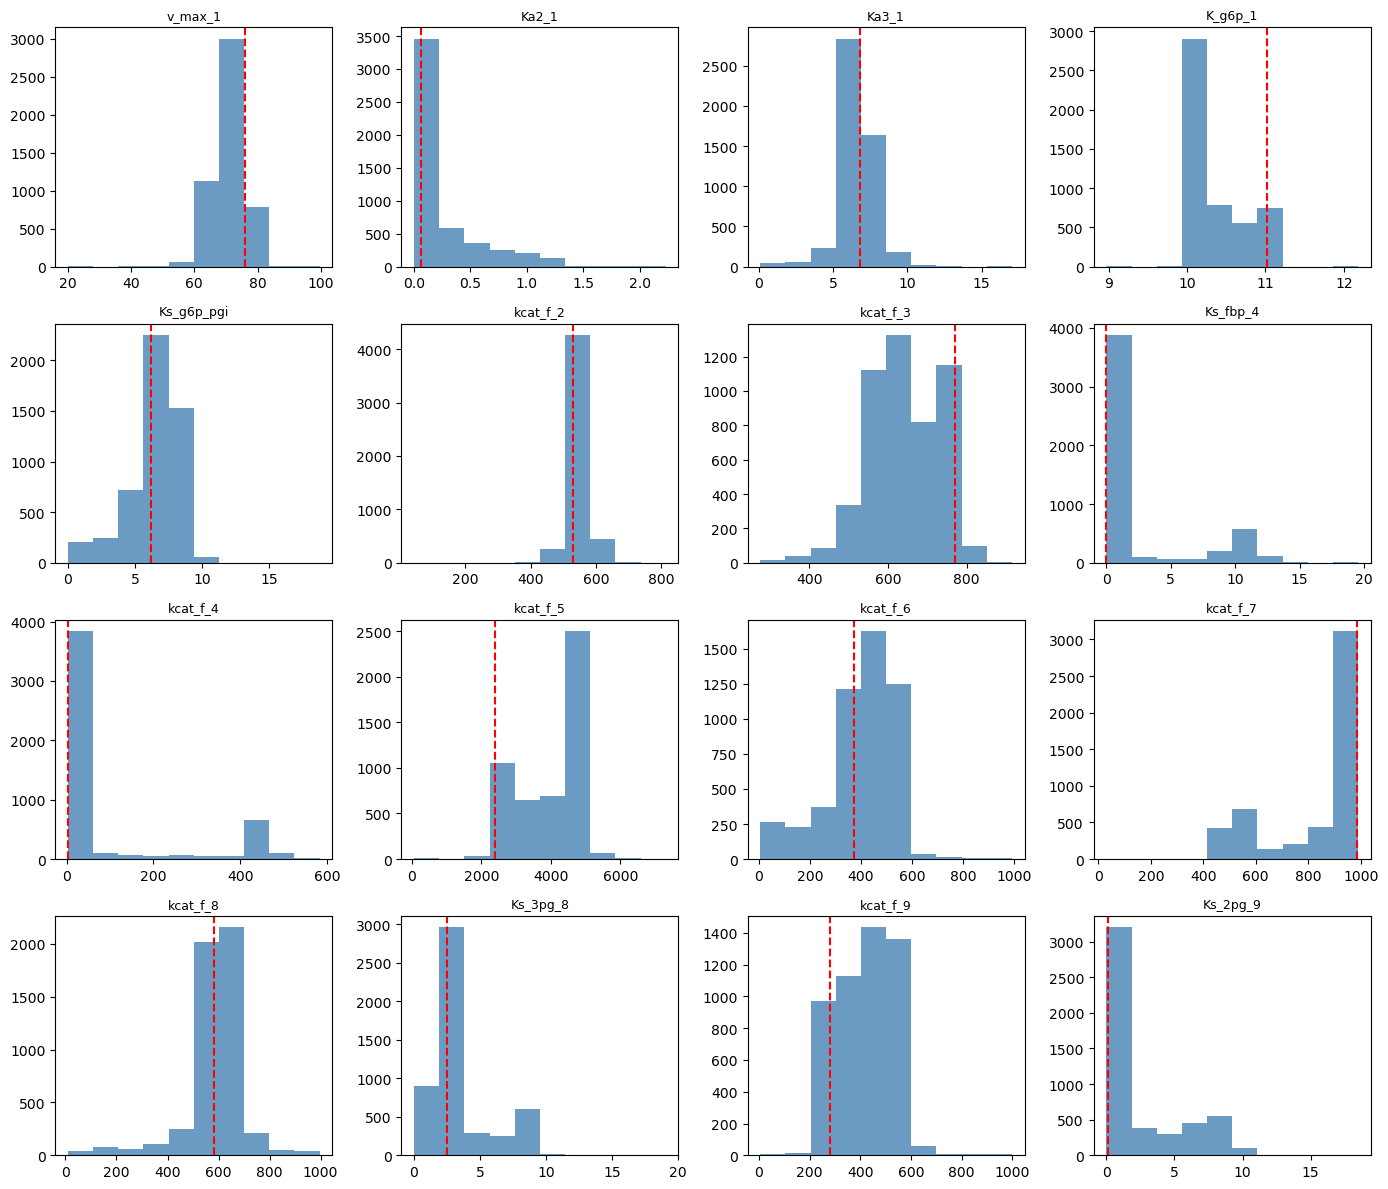

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(14, 12))
for ax, p in zip(axes.flat, free_params_third):
    ax.hist(bootstrap_theta_third[p], color="steelblue", alpha=0.8)
    ax.axvline(theta_fitted_third.loc[p, "value"], color="red", linestyle="--", label="fitted")
    ax.set_title(p, fontsize=9)
for ax in axes.flat[len(free_params_third):]:
    ax.axis("off")
fig.tight_layout()
os.makedirs(os.path.join(RESULTS_DIR, "figures"), exist_ok=True)
fig.savefig(os.path.join(RESULTS_DIR, "figures", "bootstrap_theta_hist_third.png"), dpi=150)
plt.show()

## Cross-stage comparison: does bootstrap uncertainty shrink first -> second -> third?

`third_estimation`'s 16 free parameters are a subset of `second_estimation`'s
18, which are in turn a subset of `first_estimation`'s (all 37). For those 16
parameters that stay free all the way through, compare the relative bootstrap
CI width -- `(q975 - q025) / |mean|` -- across the three stages. This is more
robust than CV% (`std/|mean|`) to the skewed/multimodal bootstrap
distributions seen for some parameters, since it reads off the actual
percentile spread rather than assuming it's well summarized by a single std.

In [ ]:
common_params = free_params_third   # already the intersection (16 <= 18 <= 37)

def ci_width_pct(summary, p):
    s = summary["stats"][p]
    return 100 * (s["q975"] - s["q025"]) / abs(s["mean"])

cross_stage = pd.DataFrame({
    "first_ci_width_pct": {p: ci_width_pct(summary_first, p) for p in common_params},
    "second_ci_width_pct": {p: ci_width_pct(summary_second, p) for p in common_params},
    "third_ci_width_pct": {p: ci_width_pct(summary_third, p) for p in common_params},
})
cross_stage.to_csv(os.path.join(RESULTS_DIR, "cross_stage_ci_width_comparison.csv"))
cross_stage

,first_ci_width_pct,second_ci_width_pct,third_ci_width_pct
v_max_1,15.763783,25.824030,23.260807
Ka2_1,336.916197,477.510591,506.257711
Ka3_1,58.230013,66.222352,75.062799
K_g6p_1,11.534749,11.215555,9.571089
Ks_g6p_pgi,137.557470,117.680258,118.440611
kcat_f_2,19.042028,25.088604,21.117416
kcat_f_3,12.053940,14.580447,49.927372
Ks_fbp_4,822.419463,706.284302,532.058736
kcat_f_4,801.760551,658.613309,494.699573
kcat_f_5,166.238020,88.770135,65.820503


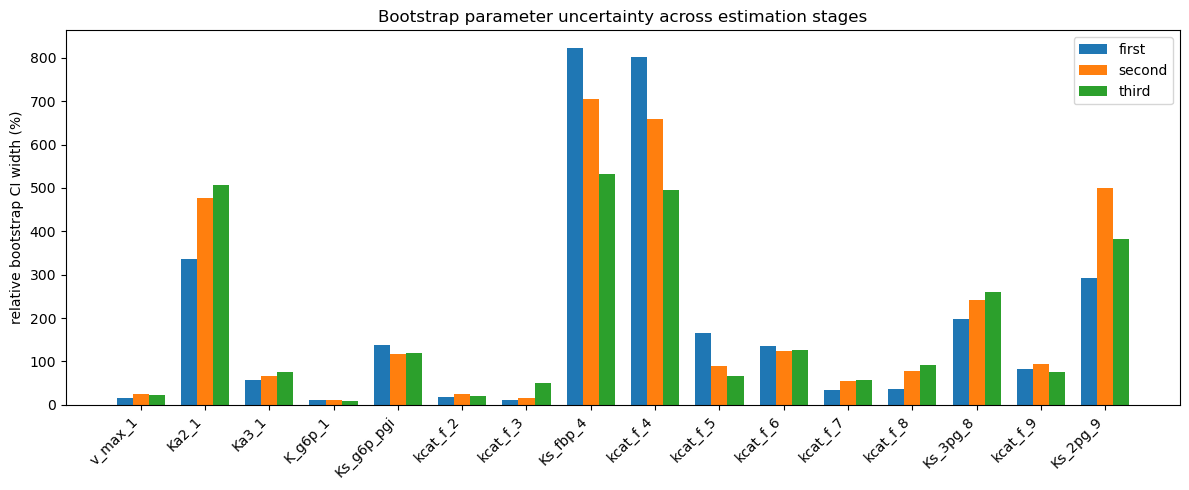

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(common_params))
width = 0.25
ax.bar(x - width, cross_stage["first_ci_width_pct"], width, label="first")
ax.bar(x, cross_stage["second_ci_width_pct"], width, label="second")
ax.bar(x + width, cross_stage["third_ci_width_pct"], width, label="third")
ax.set_xticks(x)
ax.set_xticklabels(common_params, rotation=45, ha="right")
ax.set_ylabel("relative bootstrap CI width (%)")
ax.set_title("Bootstrap parameter uncertainty across estimation stages")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "figures", "cross_stage_ci_width_comparison.png"), dpi=150)
plt.show()